In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime, timedelta
import pandas as pd
import h5py

In [2]:
file = "/datasets/FourCastNet/FCN_ERA5_data_v0/static/orography.h5"

In [3]:
with h5py.File(file, 'r') as hdf:
	keys = list(hdf.keys())
	print("Keys:", keys)
	for key in keys:
		data = hdf[key][:]
		print(f"data for key '{key}' has shape {data.shape}")
	
	fields = hdf['orog'][:]


Keys: ['orog']
data for key 'orog' has shape (721, 1440)


In [4]:
long = np.arange(-180, 180, 0.25)
lat = np.arange(-90, 90, 0.25)

In [5]:
X,Y = np.meshgrid(long, lat)


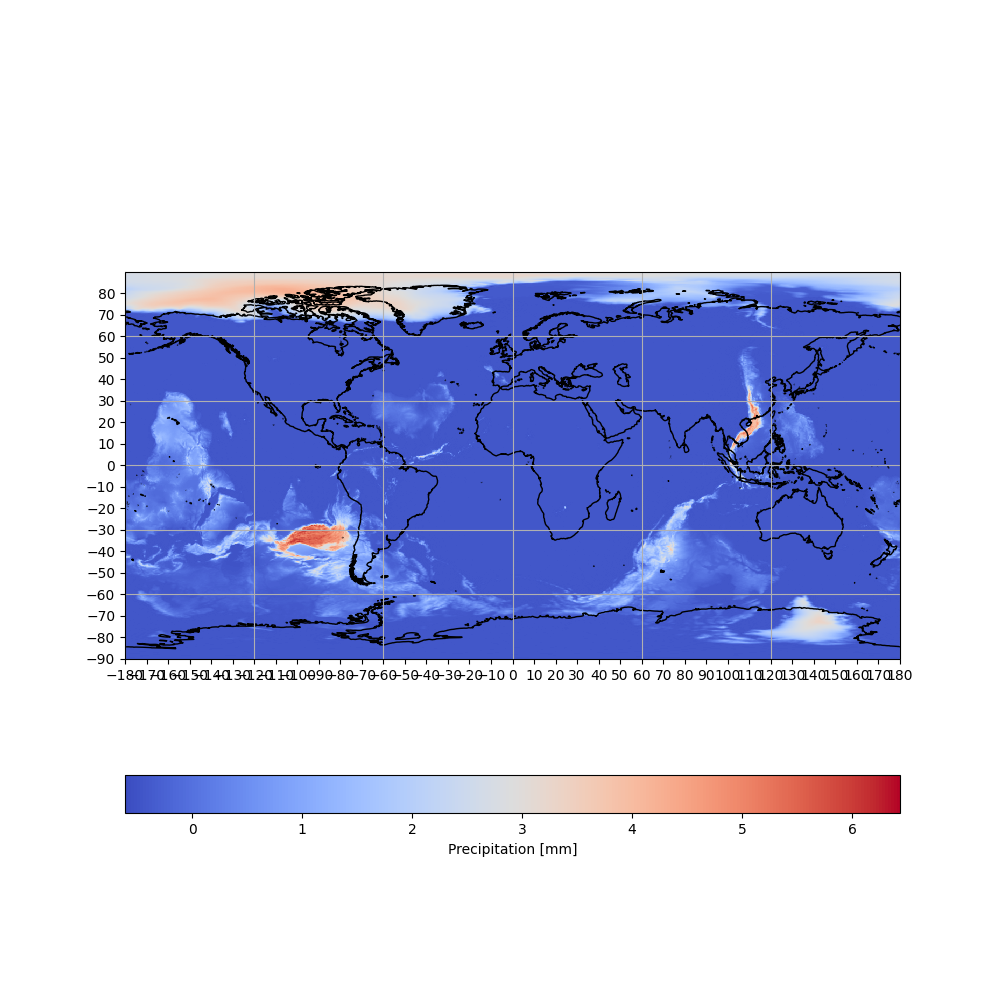

In [6]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution="50m")
ax.set_xticks(range(-180, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 10), crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=False)

ax.pcolormesh(X, Y, fields[:720, :], cmap='coolwarm')

fig.colorbar(ax.pcolormesh(X, Y, fields[:720, :], cmap='coolwarm'), ax=ax, orientation='horizontal', label='Precipitation [mm]')
